In [1]:
#loading the csv file 
import os
print("wir sind:",os.getcwd())
os.chdir("C:/Users/Robert Glantz/feb26_bds_int_supply_chain/project_supply_chain/")
import pandas as pd
pd.set_option('display.max_columns', None)
df=pd.read_csv("src/data/clean/reviews_processed.csv",sep=",")

wir sind: c:\Users\Robert Glantz\feb26_bds_int_supply_chain\project_supply_chain\src\features


In [ ]:
#Sentiment Analyse(sehr starkes neues feature sentiment!!!)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if pd.isna(text):
        return None
    return analyzer.polarity_scores(text)["compound"]

df["sentiment"] = df["review_text"].apply(get_sentiment)

In [8]:
print (df["sentiment"].head(1000).sort_values(ascending=True))

#Was das bedeutet:compound ist eine zahl zwischen -1 und +1 wobei:
#+1 extrem positiv
#0 neutral
#-1 extrem negativ
print(df.head(1000))

803   -0.9946
185   -0.9831
875   -0.9829
886   -0.9826
817   -0.9808
        ...  
981    0.9822
690    0.9832
924    0.9834
479    0.9837
905    0.9896
Name: sentiment, Length: 1000, dtype: float64
     rating                                        review_text  \
0       5.0  Alles top. Wenn man sich einmal registriert ha...   
1       5.0  Thg- Experten made a great Job. However the po...   
2       4.0  Thg did what they promised to do and paid out ...   
3       4.0  Process to place the order was very easy. Info...   
4       5.0  All well done, efficient, fast and transparent...   
..      ...                                                ...   
995     4.0             Its a good site, and a lot of options!   
996     5.0  Exellent website perfect for searching for mot...   
997     5.0  They are real And fast to respond. Kuijpers Tr...   
998     4.0  fast website, lots of possibilities to choose ...   
999     5.0                     easier access, and easy usage.   

       

             rating  sentiment
rating     1.000000   0.655492
sentiment  0.655492   1.000000


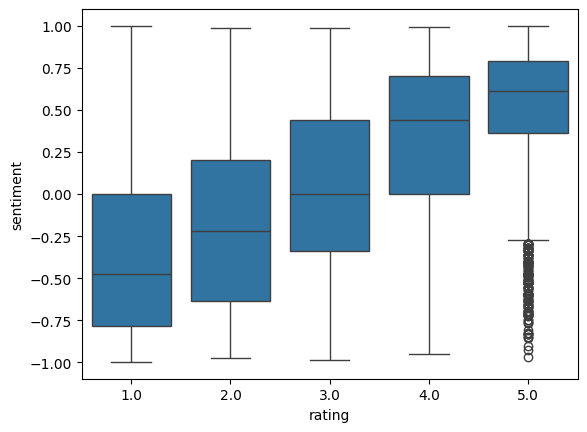

In [ ]:
print(df[["rating","sentiment"]].corr())
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="rating", y="sentiment", data=df)
plt.show()
#Sehr Starkes feature!!(+0.655)

In [ ]:
#Zweites neues sehr starkes feature!!!
#Auch sehr Starkes feature !!! (-0.577!!!)
df["has_negation"] = df["review_text"].str.contains("not|no|never", case=False)
print(df[["rating","has_negation"]].corr())
pd.crosstab(df["has_negation"], df["rating"], normalize="index")

                rating  has_negation
rating        1.000000     -0.577304
has_negation -0.577304      1.000000


rating,1.0,2.0,3.0,4.0,5.0
has_negation,,,,,
False,0.046190,0.011187,0.020492,0.080306,0.841825
True,0.463457,0.068097,0.065353,0.087054,0.316039
